In [144]:
#!/usr/bin/env python
# coding: utf-8

# In[23]:


import argparse
import json
from pathlib import Path
import math,random,os,sys, importlib, time,copy
import pickle, pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import gaussian_kde, kstest, cramervonmises, chi2, ks_2samp
from scipy import stats

import torch
from torch.utils.data import DataLoader
from joblib import Parallel, delayed
# Repo paths
PWD = Path.cwd().resolve()
ROOT = PWD.parents[0]
SRC = ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

# Local modules
import data.sample_x as sample_x_mod; importlib.reload(sample_x_mod)
import data.solve_ode as solve_ode_mod; importlib.reload(solve_ode_mod)
import data.utils as utils_mod; importlib.reload(utils_mod)
import train.training_clean as train_training; importlib.reload(train_training)

from data.sample_x import sample_x
from data.solve_ode import SpringParams, simulate_spring
from data.utils import plot_traj, check_safety, compute_mu_safety_map
from data.datasets import SpringDataset, make_sequence_pairs
from data.plotting import plot_x_safety_map, plot_mu_safety_map
from train.models import build_cond_gru_model, EncoderOnly

from train.training_clean import (
    train_eval_epoch,
    train_eval_epoch_enc_only,
    eval_epoch,
    eval_stability_classification,
    eval_regime_batch_stats
)
from train.eval import encode_to_latent

from train.losses import mmd2_unif,energy_distance_unif, cvm_unif, wasserstein1_unif
from train.training_clean import (
    DivergenceConfig,
    StabilityConfig,
    RegimeConfig,
    TrainingConfig,
    train_eval_epoch,
    train_eval_epoch_enc_only,
    eval_epoch,
)
import hypo_test.stats_tests as test_mod; importlib.reload(test_mod)
from hypo_test.stats_tests import uniformity_pvalues_all,ecdf,ks_2sample_pvalue


def parse_args(args=None) -> argparse.Namespace:
    parser = argparse.ArgumentParser(
        description="Run model diagnostics for the physics-informed hypothesis test."
    )

    
    parser.add_argument("--seed", type=int, default=1, dest="seed")
    parser.add_argument("--n-samples", type=int, default=5000, dest="n_samples")
    parser.add_argument("--T", type=float, default=10.0)
    parser.add_argument("--dt", type=float, default=0.05)
    parser.add_argument("--stride", type=int, default=1)
    parser.add_argument("--loss_type", type=str, default='stability_asymmetric_recon', dest="loss_type")# {"bce", "weighted", "weighted_bce", "stability_asymmetric_recon"}
    parser.add_argument(
        "--dist-mean",
        type=float,
        nargs=2,
        default=[0.0, 0.0],
        metavar=("MU_X", "MU_Y"),
        dest="dist_mean",
    )
    parser.add_argument(
        "--dist-cov-diag",
        type=float,
        nargs=2,
        default=[1.0, 1.0],
        metavar=("VAR_X", "VAR_Y"),
        dest="dist_cov_diag",
    )
    parser.add_argument("--batch-train", type=int, default=1024, dest="batch_train")
    parser.add_argument("--batch-val", type=int, default=512, dest="batch_val")
    parser.add_argument("--num-workers", type=int, default=4, dest="num_workers")
    parser.add_argument("--latent-batch-size", type=int, default=4096, dest="latent_batch_size")
    parser.add_argument("--epochs", type=int, default=100)
    parser.add_argument("--lr", type=float, default=5e-3, dest="lr")
    parser.add_argument("--weight-decay", type=float, default=1e-5, dest="weight_decay")
    parser.add_argument("--lr-enc", type=float, default=5e-3, dest="lr_enc")
    parser.add_argument(
        "--weight-decay-enc",
        type=float,
        default=1e-5,
        dest="weight_decay_enc",
    )
    parser.add_argument("--lambda-mmd", type=float, default=1e-2, dest="lambda_mmd")
    parser.add_argument("--d-x", type=int, default=2, dest="d_x")
    parser.add_argument("--d-o", type=int, default=1, dest="d_o")
    parser.add_argument("--d-v", type=int, default=1, dest="d_v")
    parser.add_argument("--d-h", type=int, default=128, dest="d_h")
    parser.add_argument("--hidden-enc", type=int, default=512, dest="hidden_enc")
    parser.add_argument("--hidden-dec", type=int, default=128, dest="hidden_dec")
    parser.add_argument("--B-bins", type=int, default=20, dest="B_bins")
    parser.add_argument("--tau", type=float, default=1.0)
    parser.add_argument("--asym-recon-delta", type=float, default=10.0, dest="asym_recon_delta")
    parser.add_argument(
        "--time-window",
        type=float,
        nargs=2,
        default=[6.0, 10.0],
        metavar=("T_START", "T_END"),
        dest="time_window",
    )
    parser.add_argument(
        "--lambda-stability",
        type=float,
        default=0.0,
        dest="lambda_stability",
    )
    parser.add_argument("--lambda-regime", type=float, default=0.0, dest="lambda_regime")
    parser.add_argument(
        "--output-dir",
        type=str,
        default=None,
        dest="output_dir",
    )


    args = parser.parse_args(args)

    def _fmt_float(x: float) -> str:
        return f"{x:g}".replace(".", "p")

    if args.output_dir is None:
        args.output_dir = (
            "results/diagnostics_results/"
            f"seed_{args.seed}"
            f"_lr_{_fmt_float(args.lr)}"
            f"_lambda_mmd_{_fmt_float(args.lambda_mmd)}"
            f"_loss_type_{args.loss_type}"
            # f"_epochs_{args.epochs}"
            # f"_n_{args.n_samples}"
        )
        
    args.dist_mean = np.array(args.dist_mean, dtype=float)
    args.dist_cov = np.diag(np.array(args.dist_cov_diag, dtype=float))
    args.time_window = tuple(float(v) for v in args.time_window)
    return args


Cfg = parse_args([])

print("[Config]")
print(f"  seed              : {Cfg.seed}")
print(f"  loss_type         : {Cfg.loss_type}")
print(f"  lr                : {Cfg.lr:g}")
print(f"  lr_enc            : {Cfg.lr_enc:g}")
print(f"  lambda_mmd        : {Cfg.lambda_mmd:g}")
print(f"  lambda_stability  : {Cfg.lambda_stability:g}")
print(f"  lambda_regime     : {Cfg.lambda_regime:g}")
print(f"  asym_recon_delta  : {Cfg.asym_recon_delta:g}")
print(f"  seed              : {Cfg.seed}")
print(f"  epochs            : {Cfg.epochs}")
print(f"  n_samples         : {Cfg.n_samples}")
print(f"  output_dir        : {Cfg.output_dir}")


# Reproducibility
torch.manual_seed(Cfg.seed)
np.random.seed(Cfg.seed)
random.seed(Cfg.seed)

# Device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print("device:", device)


[Config]
  seed              : 1
  loss_type         : stability_asymmetric_recon
  lr                : 0.005
  lr_enc            : 0.005
  lambda_mmd        : 0.01
  lambda_stability  : 0
  lambda_regime     : 0
  asym_recon_delta  : 10
  seed              : 1
  epochs            : 100
  n_samples         : 5000
  output_dir        : results/diagnostics_results/seed_1_lr_0p005_lambda_mmd_0p01_loss_type_stability_asymmetric_recon
device: cuda


In [145]:


z_0 = np.array([0.0, 0.0]) # baselien config
params = SpringParams(mass=1.0, damping=1.0, stiffness=2.0) # paramters theta

X = sample_x(
    n_samples=Cfg.n_samples,
    dist_type="gaussian",
    params={"mean": Cfg.dist_mean, "cov": Cfg.dist_cov},
    seed=Cfg.seed,
)

traj = simulate_spring(params, t_final=Cfg.T, dt=Cfg.dt, X=X, forcing_type="sin", config=z_0)
s = traj["s"]                           # (N, T_full)
assert X.shape[0] == s.shape[0]


y = check_safety(
    traj=traj,
    threshold=Cfg.tau,
    window=Cfg.time_window,
).astype(np.float32)


o_hist,o_next = make_sequence_pairs( s=s,stride=Cfg.stride)
x_np   = X.astype(np.float32)

print("Shapes -> X:", x_np.shape, "trajectory shape:", s.shape)

N = x_np.shape[0]
perm = np.random.RandomState(Cfg.seed).permutation(N)
n_train = int(0.8 * N)
tr_idx, va_idx = perm[:n_train], perm[n_train:]

train_ds = SpringDataset(x_np[tr_idx], o_hist[tr_idx], o_next[tr_idx], y=y[tr_idx])
val_ds   = SpringDataset(x_np[va_idx], o_hist[va_idx], o_next[va_idx], y=y[va_idx])

loader_kwargs = {
    "num_workers": max(int(Cfg.num_workers), 0),
    "pin_memory": device.type == "cuda",
}
if loader_kwargs["num_workers"] > 0:
    loader_kwargs["persistent_workers"] = True

train_loader = DataLoader(
    train_ds,
    batch_size=Cfg.batch_train,
    shuffle=True,
    drop_last=True,
    **loader_kwargs,
)
val_loader = DataLoader(
    val_ds,
    batch_size=Cfg.batch_val,
    shuffle=False,
    **loader_kwargs,
)

Shapes -> X: (5000, 2) trajectory shape: (5000, 201)


In [146]:
Cfg.lambda_mmd =  0.1
# div_fn = cvm_unif # cvm_unif # or wasserstein1_unif 
# div_kwargs = {}
div_fn = mmd2_unif
div_kwargs = {"sigmas": None, "low_discrepancy": True}


train_cfg = TrainingConfig(
    divergence=DivergenceConfig(lambda_mmd=Cfg.lambda_mmd, fn=div_fn, kwargs=div_kwargs),
    stability=StabilityConfig(
        loss_type=Cfg.loss_type,
        threshold=Cfg.tau,
        asym_recon_delta=Cfg.asym_recon_delta,
    ),
)

baseline_model_cfg = DivergenceConfig(
    lambda_mmd=Cfg.lambda_mmd,
    fn=div_fn,
    kwargs=div_kwargs,
)

model = build_cond_gru_model(
    d_x=Cfg.d_x,
    d_o=Cfg.d_o,
    d_v=Cfg.d_v,
    d_h=Cfg.d_h,
    enc_layers=2,
    dec_layers=1,
    hidden_enc=Cfg.hidden_enc,
    hidden_dec=Cfg.hidden_dec,
    output_activation="sigmoid",
    dropout_rnn=0.1,
).to(device)

model_enc = EncoderOnly(copy.deepcopy(model.enc)).to(device)

opt = torch.optim.Adam(model.parameters(), lr=Cfg.lr, weight_decay=Cfg.weight_decay)
opt_enc = torch.optim.Adam(model_enc.parameters(), lr=Cfg.lr_enc, weight_decay=Cfg.weight_decay_enc)


def evaluate_split_metrics(loader, split_name):
    rec, div = eval_epoch(
        loader=loader,
        model=model,
        device=device,
        config=train_cfg,
    )
    total = rec + Cfg.lambda_mmd * div
    metrics = {
        f"{split_name}_recon": float(rec),
        f"{split_name}_divergence": float(div),
        f"{split_name}_total_loss": float(total),
    }
    if train_cfg.stability.threshold is not None:
        cls = eval_stability_classification(
            loader=loader,
            model=model,
            device=device,
            stability=train_cfg.stability,
        )
        metrics.update(
            {
                f"{split_name}_safety_acc": cls["overall_acc"],
                f"{split_name}_safety_y1_acc": cls["y1_correct_frac"],
                f"{split_name}_safety_y0_acc": cls["y0_correct_frac"],
                f"{split_name}_frac_y1": cls["frac_y1"],
                f"{split_name}_frac_y0": cls["frac_y0"],
            }
        )
    return metrics


@torch.no_grad()
def build_reconstruction_snapshot(loader, split_name, max_samples=8):
    batch = next(iter(loader))
    x_b, o_hist_b, o_next_b, y_b = batch
    non_blocking = device.type == "cuda"
    x_b = x_b[:max_samples].to(device, non_blocking=non_blocking)
    o_hist_b = o_hist_b[:max_samples].to(device, non_blocking=non_blocking)
    o_next_b = o_next_b[:max_samples].to(device, non_blocking=non_blocking)
    y_slice = None if y_b is None else y_b[:max_samples]

    model.eval()
    o_hat_b, _ = model(x_b, o_hist_b)
    per_sample_mse = torch.mean((o_hat_b - o_next_b) ** 2, dim=(1, 2))

    snapshot = pd.DataFrame(
        {
            "split": split_name,
            "sample_idx": np.arange(x_b.shape[0]),
            "recon_mse": per_sample_mse.detach().cpu().numpy(),
            "x": list(x_b.detach().cpu().numpy()),
            "o_hist": list(o_hist_b.detach().cpu().numpy()),
            "o_next_true": list(o_next_b.detach().cpu().numpy()),
            "o_next_pred": list(o_hat_b.detach().cpu().numpy()),
        }
    )
    if y_slice is not None:
        snapshot["y"] = list(np.asarray(y_slice[: x_b.shape[0]]))
    return snapshot


history = []
best_val_mmd = float("inf")
best_state = None
use_val = val_loader is not None

for epoch in range(1, Cfg.epochs + 1):
    tr_loss, val_rec, val_div = train_eval_epoch(
        model=model,
        train_loader=train_loader,
        optimizer=opt,
        device=device,
        config=train_cfg,
        val_loader=val_loader if use_val else None,
    )

    tr_div_enc, val_div_enc = train_eval_epoch_enc_only(
        model_enc=model_enc,
        train_loader=train_loader,
        optimizer=opt_enc,
        device=device,
        divergence=baseline_model_cfg,
        val_loader=val_loader if use_val else None,
    )

    train_metrics = evaluate_split_metrics(train_loader, "train")
    val_metrics = evaluate_split_metrics(val_loader, "val") if use_val else {
        "val_recon": None,
        "val_divergence": None,
        "val_total_loss": None,
        "val_safety_acc": None,
        "val_safety_y1_acc": None,
        "val_safety_y0_acc": None,
        "val_frac_y1": None,
        "val_frac_y0": None,
    }

    history.append({
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_loss": (None if val_rec is None or val_div is None else val_rec + Cfg.lambda_mmd * val_div),
        "val_recon_raw": val_rec,
        "val_divergence_raw": val_div,
        "train_div (enc-only)": tr_div_enc,
        "val_divergence (enc-only)": val_div_enc,
        **train_metrics,
        **val_metrics,
    })

    if use_val and val_div is not None and val_div < best_val_mmd:
        best_val_mmd = val_div
        best_state = model.state_dict()

    if epoch % 10 == 0 or epoch == 1:
        msg = (
            f"[{epoch:02d}] train-loss={tr_loss:.6f}"
            f" train-recon={train_metrics['train_recon']:.6f}"
            f" train-acc={train_metrics.get('train_safety_acc', float('nan')):.4f}"
        )
        if use_val:
            msg += (
                f"  val-recon={val_metrics['val_recon']:.6f}"
                f"  val-divergence={val_metrics['val_divergence']:.6f}"
                f"  val-acc={val_metrics.get('val_safety_acc', float('nan')):.4f}"
                f"  train-divergence (enc)={tr_div_enc:.6f}"
                f"  val-divergence (enc)={val_div_enc:.6f}"
            )
        print(msg)

if use_val and best_state is not None:
    model.load_state_dict(best_state)


[01] train-loss=0.429073 train-recon=0.039188 train-acc=0.9173  val-recon=0.044414  val-divergence=0.069268  val-acc=0.9130  train-divergence (enc)=0.231646  val-divergence (enc)=0.068352
[10] train-loss=0.009155 train-recon=0.002319 train-acc=0.9401  val-recon=0.002487  val-divergence=0.016218  val-acc=0.9350  train-divergence (enc)=0.003929  val-divergence (enc)=0.002934
[20] train-loss=0.001339 train-recon=0.000980 train-acc=0.9772  val-recon=0.001037  val-divergence=-0.000457  val-acc=0.9770  train-divergence (enc)=0.002388  val-divergence (enc)=0.001980
[30] train-loss=0.000488 train-recon=0.000369 train-acc=0.9613  val-recon=0.000390  val-divergence=0.007876  val-acc=0.9700  train-divergence (enc)=0.001702  val-divergence (enc)=0.000813
[40] train-loss=0.000454 train-recon=0.000270 train-acc=0.9622  val-recon=0.000287  val-divergence=-0.000718  val-acc=0.9690  train-divergence (enc)=0.010296  val-divergence (enc)=0.012108
[50] train-loss=0.000167 train-recon=0.000091 train-acc=0.

[Uniformity p-values vs Unif(0,1)]


,split,method,KS_p,CvM_p,MMD_p,ED_p,Chi2
0,train,proposed,0.994626,9.949105e-01,1.0,1.0,0.920383
1,train,baseline,0.000003,3.067639e-08,1.0,1.0,0.920383
2,test,proposed,0.083191,1.018443e-01,1.0,1.0,0.168422
3,test,baseline,0.000006,3.617234e-07,1.0,1.0,0.168422


/tmp/ipykernel_113759/694364616.py:13: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(dens, grid)


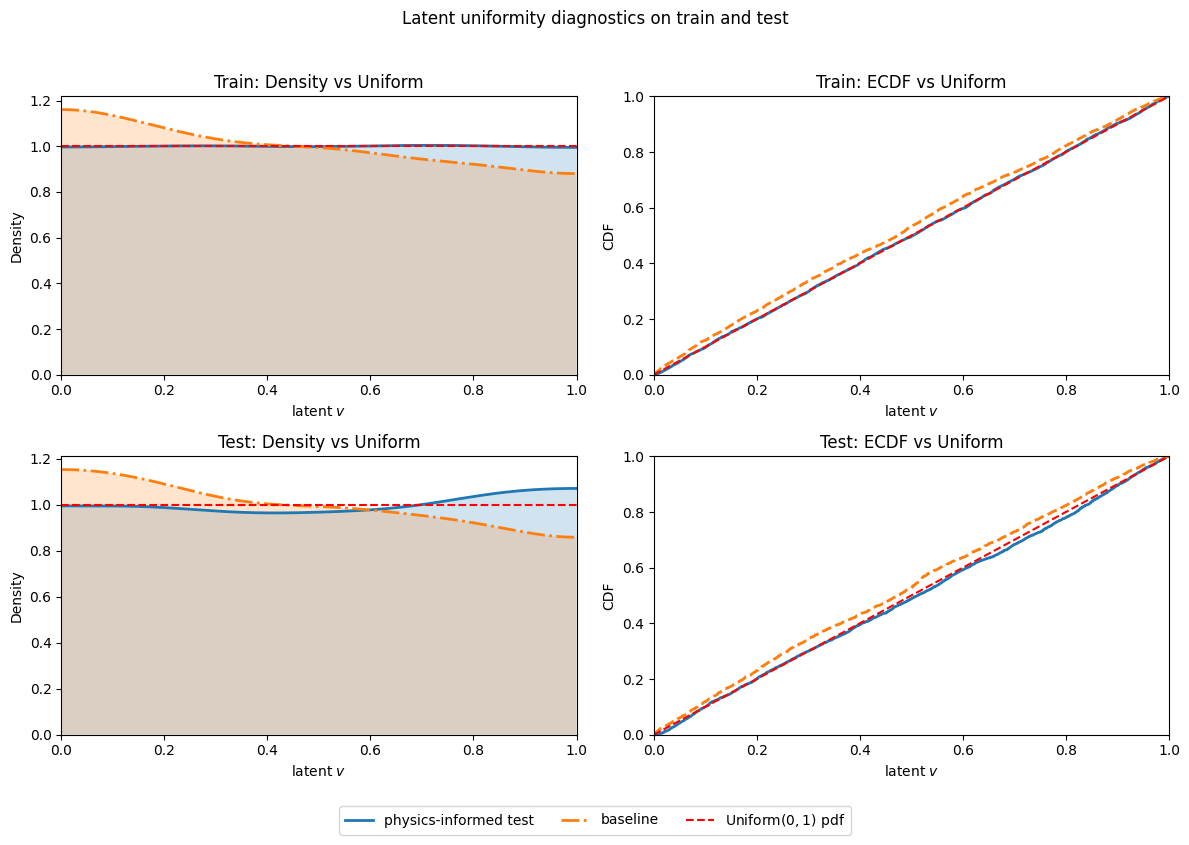

In [147]:

def bounded_kde(x, grid, low=0.0, high=1.0):
    x = np.asarray(x)
    x_reflect = np.concatenate([
        x,
        2 * low - x,
        2 * high - x,
    ])
    kde = gaussian_kde(x_reflect)
    dens = kde(grid)

    dens = np.where((grid >= low) & (grid <= high), dens, 0.0)

    area = np.trapz(dens, grid)
    if area > 0:
        dens = dens / area
    return dens


X_splits = {
    "train": x_np[tr_idx],
    "val": x_np[va_idx],
    "test": sample_x(
        n_samples=3000,
        dist_type="gaussian",
        params={"mean": np.array([0, 0]), "cov": np.diag([1, 1])},
        seed=2,
    ).astype(np.float32),
}

# -----------------------
# 1) compute latents per split
# -----------------------
latents = {}
for split_name in ["train", "test"]:
    X = X_splits[split_name]
    latents[split_name] = {
        "proposed": encode_to_latent(model, X, device)[:, 0],
        "baseline": encode_to_latent(model_enc, X, device)[:, 0],
    }
# -----------------------
# 2) p-values table
# -----------------------
rows = []
for split_name in ["train", "test"]:
    v_np = latents[split_name]["proposed"]
    v0_np = latents[split_name]["baseline"]
    


    pvals = uniformity_pvalues_all(v_np, v0_np, device=device, B=0, seed=0)

    for method_name in ["proposed", "baseline"]:
        row = {"split": split_name, "method": method_name}
        for key, value in pvals[method_name].items():
            if "stat" in key:
                continue
            row[key] = value
        rows.append(row)

pvals_df = pd.DataFrame(rows)
print("[Uniformity p-values vs Unif(0,1)]")
display(pvals_df)

# -----------------------
# 3) make 2x2 plot
# -----------------------
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=False)

for row_idx, split_name in enumerate(["train", "test"]):
    v_np = latents[split_name]["proposed"]
    v0_np = latents[split_name]["baseline"]

    grid = np.linspace(0, 1, 400)
    kde_v = bounded_kde(v_np, grid, low=0.0, high=1.0)
    kde_v0 = bounded_kde(v0_np, grid, low=0.0, high=1.0)

    x1, y1 = ecdf(v_np)
    x2, y2 = ecdf(v0_np)

    # Left: KDE vs uniform pdf
    ax = axes[row_idx, 0]
    ax.plot(grid, kde_v, linewidth=2, label="physics-informed test")
    ax.fill_between(grid, 0, kde_v, alpha=0.20)
    ax.plot(grid, kde_v0, linewidth=2, linestyle="-.", label="baseline")
    ax.fill_between(grid, 0, kde_v0, alpha=0.20)
    ax.axhline(1.0, linestyle="--", color="red", label=r"Uniform$(0,1)$ pdf")
    ax.set_xlim(0, 1)
    ax.set_ylim(bottom=0)
    ax.set_xlabel(r"latent $v$")
    ax.set_ylabel("Density")
    ax.set_title(f"{split_name.capitalize()}: Density vs Uniform")

    # Right: ECDF vs uniform cdf
    ax = axes[row_idx, 1]
    ax.plot(x1, y1, linewidth=2, label="proposed (ECDF)")
    ax.plot(x2, y2, linewidth=2, linestyle="--", label="baseline (ECDF)")
    ax.plot([0, 1], [0, 1], linestyle="--", color="red", label=r"Uniform$(0,1)$ CDF")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_xlabel(r"latent $v$")
    ax.set_ylabel("CDF")
    ax.set_title(f"{split_name.capitalize()}: ECDF vs Uniform")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3, frameon=True, bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Latent uniformity diagnostics on train and test", y=1.02)
fig.tight_layout(rect=[0, 0.04, 1, 1])
plt.show()


In [148]:
def _anderson_2sample_pvalue(x, y):
    res = stats.anderson_ksamp([np.asarray(x, float).ravel(), np.asarray(y, float).ravel()])
    return float(res.significance_level) / 100.0


def _cvm_2sample_pvalue(x, y):
    res = stats.cramervonmises_2samp(np.asarray(x, float).ravel(), np.asarray(y, float).ravel())
    return float(res.pvalue)


def _uniform_reference_metrics(v_np, *, device, ref_u_np):
    v_np = np.clip(np.asarray(v_np, float).ravel(), 0.0, 1.0)
    ref_u_np = np.asarray(ref_u_np, float).ravel()

    ks_res = stats.kstest(v_np, "uniform", args=(0.0, 1.0))
    wass = stats.wasserstein_distance(v_np, ref_u_np)

    v_t = torch.as_tensor(v_np, device=device, dtype=torch.float32).view(-1, 1)
    ref_u_t = torch.as_tensor(ref_u_np, device=device, dtype=torch.float32).view(-1, 1)
    mmd = float(mmd2_unif(v_t, sigmas=None, ref_u=ref_u_t, use_median=False).item())

    return {
        "ks_stat": float(ks_res.statistic),
        "ks_pvalue": float(ks_res.pvalue),
        "mmd": mmd,
        "wasserstein": float(wass),
    }


def _mean_std(values):
    arr = np.asarray(values, dtype=float)
    return float(np.mean(arr)), float(np.std(arr))


def sweep_direction_parallel_twosample_ks(
    mu_base,
    direction,
    deltas,
    *,
    n_samples=3000,
    cov=np.diag([1., 1.]),
    truncate_box=None,
    seed=1,
    n_reps=10,
    n_jobs=-1,
    backend="threading",
):
    if device.type == "cuda" and n_jobs != 1:
        print(
            f"[sweep] device=cuda: forcing n_jobs=1 (requested {n_jobs}) to avoid GPU contention."
        )
        n_jobs = 1

    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**32 - 1, size=len(deltas) * n_reps, dtype=np.uint32)
    cov = np.asarray(cov, float)

    def one(delta, rep_seed):
        rep_seed = int(rep_seed)
        mu_shift = np.asarray(mu_base, float) + float(delta) * np.asarray(direction, float)

        # baseline sample
        X0 = sample_x(
            n_samples=n_samples,
            dist_type="gaussian",
            params={"mean": np.asarray((0,0), float), "cov": cov},
            seed=rep_seed,
            truncate_box=truncate_box,
        ).astype(np.float32)

        # shifted sample (different seed to avoid identical draws)
        X1 = sample_x(
            n_samples=n_samples,
            dist_type="gaussian",
            params={"mean": mu_shift, "cov": cov},
            seed=rep_seed + 99991,
            truncate_box=truncate_box,
        ).astype(np.float32)

        # encode both samples for both models
        v0_p = encode_to_latent(model,     X0, device, batch_size=Cfg.latent_batch_size)[:, 0]
        v1_p = encode_to_latent(model,     X1, device, batch_size=Cfg.latent_batch_size)[:, 0]
        v0_b = encode_to_latent(model_enc, X0, device, batch_size=Cfg.latent_batch_size)[:, 0]
        v1_b = encode_to_latent(model_enc, X1, device, batch_size=Cfg.latent_batch_size)[:, 0]

        # Two-sample p-values: baseline latent vs shifted latent.
        ks_p_prop = ks_2sample_pvalue(v0_p, v1_p)
        ks_p_base = ks_2sample_pvalue(v0_b, v1_b)
        cvm_p_prop = _cvm_2sample_pvalue(v0_p, v1_p)
        cvm_p_base = _cvm_2sample_pvalue(v0_b, v1_b)
        ad_p_prop = _anderson_2sample_pvalue(v0_p, v1_p)
        ad_p_base = _anderson_2sample_pvalue(v0_b, v1_b)

        # Uniform-reference diagnostics on shifted latent only.
        ref_rng = np.random.default_rng(rep_seed + 424242)
        ref_u_np = ref_rng.uniform(0.0, 1.0, size=v1_p.shape[0]).astype(np.float32)
        uniform_prop = _uniform_reference_metrics(v1_p, device=device, ref_u_np=ref_u_np)
        uniform_base = _uniform_reference_metrics(v1_b, device=device, ref_u_np=ref_u_np)

        return {
            "delta": float(delta),
            "mu1": float(mu_shift[0]),
            "mu2": float(mu_shift[1]),
            "ks_p_prop": float(ks_p_prop),
            "ks_p_base": float(ks_p_base),
            "cvm_p_prop": float(cvm_p_prop),
            "cvm_p_base": float(cvm_p_base),
            "ad_p_prop": float(ad_p_prop),
            "ad_p_base": float(ad_p_base),
            "ks_u_stat_prop": uniform_prop["ks_stat"],
            "ks_u_stat_base": uniform_base["ks_stat"],
            "ks_u_p_prop": uniform_prop["ks_pvalue"],
            "ks_u_p_base": uniform_base["ks_pvalue"],
            "mmd_u_prop": uniform_prop["mmd"],
            "mmd_u_base": uniform_base["mmd"],
            "wass_u_prop": uniform_prop["wasserstein"],
            "wass_u_base": uniform_base["wasserstein"],
        }

    tasks = [(delta, seeds[i * n_reps + j]) for i, delta in enumerate(deltas) for j in range(n_reps)]
    results = Parallel(n_jobs=n_jobs, backend=backend)(delayed(one)(delta, s) for delta, s in tasks)

    rows = []
    for i, delta in enumerate(deltas):
        chunk = results[i * n_reps : (i + 1) * n_reps]
        mu1, mu2 = chunk[0]["mu1"], chunk[0]["mu2"]

        ks_p_prop = np.array([r["ks_p_prop"] for r in chunk], dtype=float)
        ks_p_base = np.array([r["ks_p_base"] for r in chunk], dtype=float)
        cvm_p_prop = np.array([r["cvm_p_prop"] for r in chunk], dtype=float)
        cvm_p_base = np.array([r["cvm_p_base"] for r in chunk], dtype=float)
        ad_p_prop = np.array([r["ad_p_prop"] for r in chunk], dtype=float)
        ad_p_base = np.array([r["ad_p_base"] for r in chunk], dtype=float)
        ks_u_stat_prop = np.array([r["ks_u_stat_prop"] for r in chunk], dtype=float)
        ks_u_stat_base = np.array([r["ks_u_stat_base"] for r in chunk], dtype=float)
        ks_u_p_prop = np.array([r["ks_u_p_prop"] for r in chunk], dtype=float)
        ks_u_p_base = np.array([r["ks_u_p_base"] for r in chunk], dtype=float)
        mmd_u_prop = np.array([r["mmd_u_prop"] for r in chunk], dtype=float)
        mmd_u_base = np.array([r["mmd_u_base"] for r in chunk], dtype=float)
        wass_u_prop = np.array([r["wass_u_prop"] for r in chunk], dtype=float)
        wass_u_base = np.array([r["wass_u_base"] for r in chunk], dtype=float)

        ks_p_prop_mean, ks_p_prop_std = _mean_std(ks_p_prop)
        ks_p_base_mean, ks_p_base_std = _mean_std(ks_p_base)
        cvm_p_prop_mean, cvm_p_prop_std = _mean_std(cvm_p_prop)
        cvm_p_base_mean, cvm_p_base_std = _mean_std(cvm_p_base)
        ad_p_prop_mean, ad_p_prop_std = _mean_std(ad_p_prop)
        ad_p_base_mean, ad_p_base_std = _mean_std(ad_p_base)
        ks_u_stat_prop_mean, ks_u_stat_prop_std = _mean_std(ks_u_stat_prop)
        ks_u_stat_base_mean, ks_u_stat_base_std = _mean_std(ks_u_stat_base)
        mmd_u_prop_mean, mmd_u_prop_std = _mean_std(mmd_u_prop)
        mmd_u_base_mean, mmd_u_base_std = _mean_std(mmd_u_base)
        wass_u_prop_mean, wass_u_prop_std = _mean_std(wass_u_prop)
        wass_u_base_mean, wass_u_base_std = _mean_std(wass_u_base)

        rows.append({
            "delta": float(delta),
            "mu1": float(mu1),
            "mu2": float(mu2),
            "pval": ks_p_prop,
            "pval_base": ks_p_base,
            "ks_p_prop": ks_p_prop,
            "ks_p_base": ks_p_base,
            "cvm_p_prop": cvm_p_prop,
            "cvm_p_base": cvm_p_base,
            "ad_p_prop": ad_p_prop,
            "ad_p_base": ad_p_base,
            "ks_u_stat_prop": ks_u_stat_prop,
            "ks_u_stat_base": ks_u_stat_base,
            "ks_u_p_prop": ks_u_p_prop,
            "ks_u_p_base": ks_u_p_base,
            "mmd_u_prop": mmd_u_prop,
            "mmd_u_base": mmd_u_base,
            "wass_u_prop": wass_u_prop,
            "wass_u_base": wass_u_base,
            "ks_p_prop_mean": ks_p_prop_mean,
            "ks_p_base_mean": ks_p_base_mean,
            "ks_p_prop_std": ks_p_prop_std,
            "ks_p_base_std": ks_p_base_std,
            "cvm_p_prop_mean": cvm_p_prop_mean,
            "cvm_p_base_mean": cvm_p_base_mean,
            "cvm_p_prop_std": cvm_p_prop_std,
            "cvm_p_base_std": cvm_p_base_std,
            "ad_p_prop_mean": ad_p_prop_mean,
            "ad_p_base_mean": ad_p_base_mean,
            "ad_p_prop_std": ad_p_prop_std,
            "ad_p_base_std": ad_p_base_std,
            "ks_u_stat_prop_mean": ks_u_stat_prop_mean,
            "ks_u_stat_base_mean": ks_u_stat_base_mean,
            "ks_u_stat_prop_std": ks_u_stat_prop_std,
            "ks_u_stat_base_std": ks_u_stat_base_std,
            "mmd_u_prop_mean": mmd_u_prop_mean,
            "mmd_u_base_mean": mmd_u_base_mean,
            "mmd_u_prop_std": mmd_u_prop_std,
            "mmd_u_base_std": mmd_u_base_std,
            "wass_u_prop_mean": wass_u_prop_mean,
            "wass_u_base_mean": wass_u_base_mean,
            "wass_u_prop_std": wass_u_prop_std,
            "wass_u_base_std": wass_u_base_std,
        })

    return pd.DataFrame(rows)


# In[29]:


deltas = np.linspace(0, 1, 11)
truncate_box = (-3.0, 3.0)
n_reps = 20
n_jobs=1 if device.type == "cuda" else 15

seed = 10
df1 = sweep_direction_parallel_twosample_ks(mu_base=(0,0),  direction=(0,1), deltas=deltas,
                                  truncate_box=truncate_box, n_reps=n_reps,n_jobs=n_jobs,seed=seed)
df2 = sweep_direction_parallel_twosample_ks(mu_base=(0,0),  direction=(1,0), deltas=deltas,
                                  truncate_box=truncate_box, n_reps=n_reps,n_jobs=n_jobs,seed=seed)
df3 = sweep_direction_parallel_twosample_ks(mu_base=(-1,0), direction=(0,1), deltas=deltas,
                                  truncate_box=truncate_box, n_reps=n_reps,n_jobs=n_jobs)



# In[ ]:


dfs = {
    "df1": df1,
    "df2": df2,
    "df3": df3,
}

/tmp/ipykernel_113759/1695955780.py:2: UserWarning: p-value capped: true value larger than 0.25. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  res = stats.anderson_ksamp([np.asarray(x, float).ravel(), np.asarray(y, float).ravel()])
/tmp/ipykernel_113759/1695955780.py:2: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  res = stats.anderson_ksamp([np.asarray(x, float).ravel(), np.asarray(y, float).ravel()])


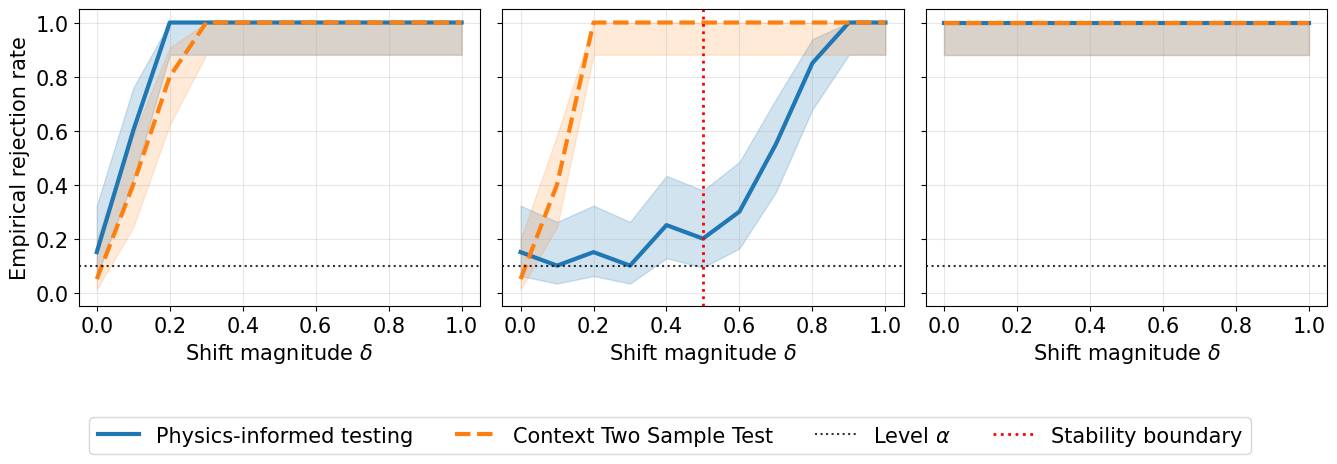

In [149]:

def plot_power_three(
    df1,
    df2,
    df3,
    *,
    alpha=0.1,
    boundary_delta=0.5,
    show_oracle=True,
    oracle_jitter=0.015,
    seed=0,
    band=None,                 # None, "std", "quantile", "wilson", "normal_ci"
    quantiles=(0.2, 0.8),      # used when band="quantile"
    ci_level=0.95,             # used when band in {"wilson", "normal_ci"}
    figsize=(15, 6),
    title_fs=14,
    label_fs=14,
    tick_fs=12,
    legend_fs=12,
):
    import numpy as np
    import matplotlib.pyplot as plt

    def _to_array_list(series):
        return [np.asarray(x) for x in series]

    def _z_value(level):
        # Common fixed values to avoid scipy dependency
        z_map = {
            0.90: 1.6448536269514722,
            0.95: 1.959963984540054,
            0.98: 2.3263478740408408,
            0.99: 2.5758293035489004,
        }
        key = round(float(level), 2)
        if key not in z_map:
            raise ValueError("ci_level must be one of {0.90, 0.95, 0.98, 0.99}")
        return z_map[key]

    def _wilson_interval(k, n, z):
        if n == 0:
            return 0.0, 0.0
        phat = k / n
        denom = 1.0 + z**2 / n
        center = (phat + z**2 / (2 * n)) / denom
        radius = z * np.sqrt((phat * (1 - phat) / n) + (z**2 / (4 * n**2))) / denom
        return max(0.0, center - radius), min(1.0, center + radius)

    def _summarize_rejection(arr_list):
        mean = np.array([np.mean(a <= alpha) for a in arr_list])

        if band is None:
            return mean, None, None

        if band == "std":
            std = np.array([
                np.std((a <= alpha).astype(float), ddof=1) if len(a) > 1 else 0.0
                for a in arr_list
            ])
            lo = np.clip(mean - std, 0.0, 1.0)
            hi = np.clip(mean + std, 0.0, 1.0)
            return mean, lo, hi

        if band == "quantile":
            ql, qh = quantiles
            lo = np.array([np.quantile((a <= alpha).astype(float), ql) for a in arr_list])
            hi = np.array([np.quantile((a <= alpha).astype(float), qh) for a in arr_list])
            return mean, lo, hi

        if band == "normal_ci":
            z = _z_value(ci_level)
            lo, hi = [], []
            for a in arr_list:
                y = (a <= alpha).astype(float)
                n = len(y)
                p = np.mean(y) if n > 0 else 0.0
                se = np.sqrt(p * (1 - p) / n) if n > 0 else 0.0
                lo.append(max(0.0, p - z * se))
                hi.append(min(1.0, p + z * se))
            return mean, np.array(lo), np.array(hi)

        if band == "wilson":
            z = _z_value(ci_level)
            lo, hi = [], []
            for a in arr_list:
                y = (a <= alpha).astype(int)
                n = len(y)
                k = int(y.sum())
                l, h = _wilson_interval(k, n, z)
                lo.append(l)
                hi.append(h)
            return mean, np.array(lo), np.array(hi)

        raise ValueError("band must be None, 'std', 'quantile', 'wilson', or 'normal_ci'")

    fig, axes = plt.subplots(1, 3, figsize=figsize, sharey=True)

    titles = [
        r"Setting 1 ($H_0$)",
        r"Setting 2 ($H_0 \to H_1$)",
        r"Setting 3 ($H_1$)",
    ]

    rng = np.random.default_rng(seed)

    for k, (ax, df, title) in enumerate(zip(axes, [df1, df2, df3], titles), start=1):
        delta = df["delta"].to_numpy()

        pval_prop = _to_array_list(df["pval"])
        pval_base = _to_array_list(df["pval_base"])

        rej_prop, prop_lo, prop_hi = _summarize_rejection(pval_prop)
        rej_base, base_lo, base_hi = _summarize_rejection(pval_base)

        if band is not None:
            ax.fill_between(delta, prop_lo, prop_hi, alpha=0.20, color="#1f77b4")
            ax.fill_between(delta, base_lo, base_hi, alpha=0.16, color="#ff7f0e")

        ax.plot(delta, rej_prop, lw=3, color="#1f77b4", label="Physics-informed testing")
        ax.plot(delta, rej_base, lw=3, ls="--", color="#ff7f0e", label="Context Two Sample Test")

        ax.axhline(
            alpha,
            color="k",
            ls=":",
            lw=1.5,
            alpha=0.8,
            label=(r"Level $\alpha$" if k == 2 else None),
        )

        if k == 2:
            ax.axvline(
                boundary_delta,
                color="red",
                ls=":",
                lw=2,
                label="Stability boundary",
            )

        if show_oracle:
            if k == 1:
                oracle = np.zeros_like(delta)
            elif k == 2:
                oracle = (delta >= boundary_delta).astype(float)
            else:
                oracle = np.ones_like(delta)

            oracle_j = np.clip(
                oracle + rng.uniform(-oracle_jitter, oracle_jitter, size=oracle.shape),
                0.0,
                1.0,
            )

            ax.plot(
                delta,
                oracle_j,
                lw=2.2,
                ls="-.",
                color="#444444",
                alpha=0.9,
                label=("Oracle (idealized)" if k == 2 else None),
            )

        ax.set_xlabel(r"Shift magnitude $\delta$", fontsize=label_fs)
        # ax.set_title(title, fontsize=title_fs)
        ax.set_ylim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis="both", labelsize=tick_fs)

    axes[0].set_ylabel("Empirical rejection rate", fontsize=label_fs)

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=5 if show_oracle else 4,
        bbox_to_anchor=(0.5, -0.12),
        fontsize=legend_fs,
    )

    fig.tight_layout(rect=[0, 0.08, 1, 1])
    plt.show()

# usage
alpha=0.1
plot_power_three(df1, df2, df3, band="wilson", ci_level=0.90, show_oracle=False,
                 figsize=(13.5,4.2), seed=42, alpha=alpha,
                 title_fs=20,label_fs=15,tick_fs=15, legend_fs=15)
